# Week 1 — Mathematical Foundations
## Sets, Functions & Linear Algebra

**Optimisation & Mathematical Methods for Economics**
The University of Edinburgh · School of Economics

---

This notebook reviews the core mathematical building blocks you will need throughout the course: sets, functions, vectors, matrices, and key linear algebra concepts. We pair each idea with Python/NumPy code so you can compute and visualise as you learn.

## 1. Sets and Real Analysis Essentials

A **set** is a collection of distinct objects. In economics we work mostly with subsets of $\mathbb{R}^n$.

**Key definitions:**
- **Open set:** A set $S$ is open if for every $x \in S$ there exists $\varepsilon > 0$ such that $B(x, \varepsilon) \subset S$.
- **Closed set:** A set is closed if its complement is open, or equivalently if it contains all its limit points.
- **Bounded set:** $S$ is bounded if there exists $M > 0$ such that $\|x\| \leq M$ for all $x \in S$.
- **Compact set:** A set that is both closed and bounded (in $\mathbb{R}^n$, by the Heine–Borel theorem).

**Why this matters for optimisation:** The *Extreme Value Theorem* guarantees that a continuous function on a compact set attains its maximum and minimum.

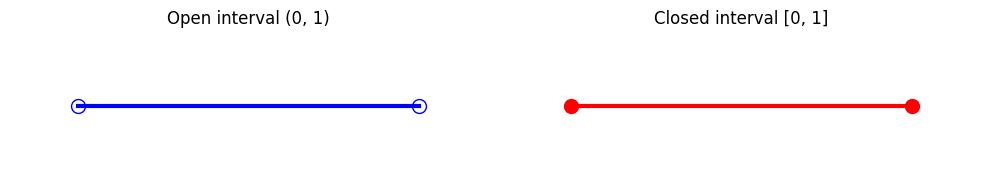

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Visualise open vs closed intervals
fig, axes = plt.subplots(1, 2, figsize=(10, 2))

# Open interval (0, 1)
axes[0].plot([0, 1], [0, 0], 'b-', linewidth=3)
axes[0].plot(0, 0, 'bo', markersize=10, fillstyle='none')  # open circle
axes[0].plot(1, 0, 'bo', markersize=10, fillstyle='none')
axes[0].set_title('Open interval (0, 1)', fontsize=12)
axes[0].set_ylim(-0.5, 0.5)
axes[0].set_xlim(-0.2, 1.2)
axes[0].axis('off')

# Closed interval [0, 1]
axes[1].plot([0, 1], [0, 0], 'r-', linewidth=3)
axes[1].plot(0, 0, 'ro', markersize=10)  # filled circle
axes[1].plot(1, 0, 'ro', markersize=10)
axes[1].set_title('Closed interval [0, 1]', fontsize=12)
axes[1].set_ylim(-0.5, 0.5)
axes[1].set_xlim(-0.2, 1.2)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 2. Vectors and Matrices with NumPy

A **vector** $\mathbf{x} \in \mathbb{R}^n$ is an ordered list of $n$ real numbers. A **matrix** $A \in \mathbb{R}^{m \times n}$ is a rectangular array.

Key operations: addition, scalar multiplication, dot product, matrix multiplication.

In [2]:
# Vectors
x = np.array([1, 2, 3])
y = np.array([4, 5, 6])

print("x =", x)
print("y =", y)
print("x + y =", x + y)
print("3x =", 3 * x)
print("x . y =", np.dot(x, y))
print("||x|| =", np.linalg.norm(x))

x = [1 2 3]
y = [4 5 6]
x + y = [5 7 9]
3x = [3 6 9]
x . y = 32
||x|| = 3.7416573867739413


In [3]:
# Matrices
A = np.array([[1, 2],
              [3, 4]])
B = np.array([[5, 6],
              [7, 8]])

print("A =\n", A)
print("\nA @ B =\n", A @ B)
print("\nA^T =\n", A.T)
print("\ndet(A) =", np.linalg.det(A))
print("\nA^{-1} =\n", np.linalg.inv(A))

A =
 [[1 2]
 [3 4]]

A @ B =
 [[19 22]
 [43 50]]

A^T =
 [[1 3]
 [2 4]]

det(A) = -2.0000000000000004

A^{-1} =
 [[-2.   1. ]
 [ 1.5 -0.5]]


## 3. Eigenvalues and Positive Definiteness

For a square matrix $A$, a scalar $\lambda$ is an **eigenvalue** if $A\mathbf{v} = \lambda \mathbf{v}$ for some non-zero vector $\mathbf{v}$ (the **eigenvector**).

A symmetric matrix $A$ is:
- **Positive definite** if all eigenvalues $> 0$ (equivalently, $\mathbf{x}^T A \mathbf{x} > 0$ for all $\mathbf{x} \neq 0$)
- **Positive semi-definite** if all eigenvalues $\geq 0$
- **Negative definite** if all eigenvalues $< 0$

**Why this matters:** The Hessian matrix being negative definite at a critical point confirms a local maximum.

In [4]:
# Eigenvalues and definiteness
H1 = np.array([[2, 0],
               [0, 3]])  # Positive definite

H2 = np.array([[-1, 0],
               [0, -2]])  # Negative definite

H3 = np.array([[1, 0],
               [0, -1]])  # Indefinite

for name, H in [("H1", H1), ("H2", H2), ("H3", H3)]:
    eigvals = np.linalg.eigvalsh(H)
    if all(eigvals > 0):
        classification = "Positive definite"
    elif all(eigvals < 0):
        classification = "Negative definite"
    elif all(eigvals >= 0):
        classification = "Positive semi-definite"
    elif all(eigvals <= 0):
        classification = "Negative semi-definite"
    else:
        classification = "Indefinite"
    print(f"{name}: eigenvalues = {eigvals}  ->  {classification}")

H1: eigenvalues = [2. 3.]  ->  Positive definite
H2: eigenvalues = [-2. -1.]  ->  Negative definite
H3: eigenvalues = [-1.  1.]  ->  Indefinite


## 4. Functions and Level Curves

A function $f: \mathbb{R}^n \to \mathbb{R}$ maps vectors to scalars. In economics, utility functions $u(x_1, x_2)$ and production functions $f(K, L)$ are key examples.

**Level curves** (or indifference curves) are the sets $\{\mathbf{x} : f(\mathbf{x}) = c\}$ for constant $c$.

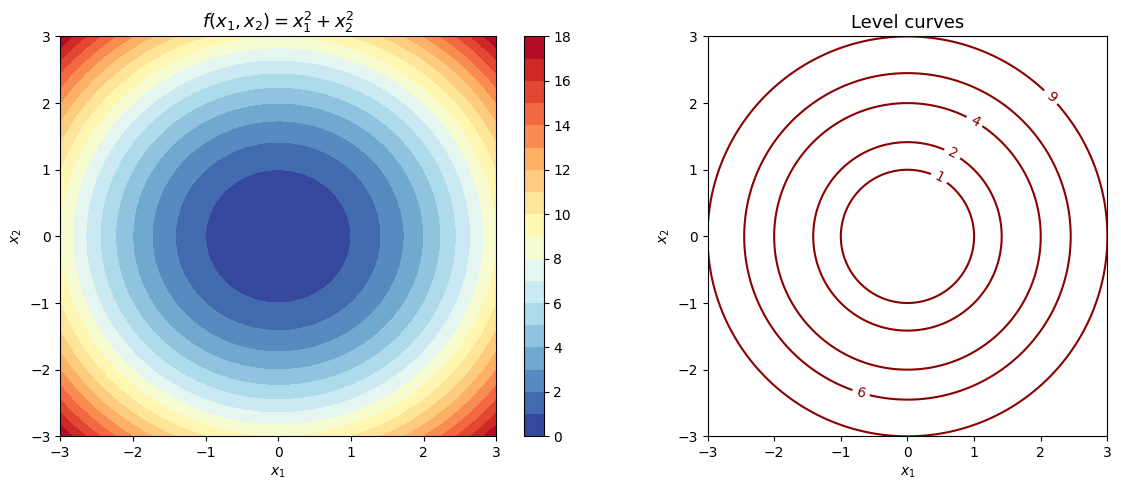

In [5]:
# Plot a function and its level curves
from mpl_toolkits.mplot3d import Axes3D

x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = X1**2 + X2**2  # Simple quadratic

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Surface plot (as contour fill)
cp = axes[0].contourf(X1, X2, Z, levels=20, cmap='RdYlBu_r')
plt.colorbar(cp, ax=axes[0])
axes[0].set_title('$f(x_1, x_2) = x_1^2 + x_2^2$', fontsize=13)
axes[0].set_xlabel('$x_1$')
axes[0].set_ylabel('$x_2$')

# Level curves
cs = axes[1].contour(X1, X2, Z, levels=[1, 2, 4, 6, 9], colors='darkred')
axes[1].clabel(cs, inline=True, fontsize=10)
axes[1].set_title('Level curves', fontsize=13)
axes[1].set_xlabel('$x_1$')
axes[1].set_ylabel('$x_2$')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

## Exercises

<details><summary><b>Exercise 1:</b> Given $A = \begin{pmatrix} 4 & 2 \\ 2 & 3 \end{pmatrix}$, compute the eigenvalues and determine if $A$ is positive definite.</summary>

```python
A = np.array([[4, 2], [2, 3]])
eigvals = np.linalg.eigvalsh(A)
print("Eigenvalues:", eigvals)
print("Positive definite:", all(eigvals > 0))
# Eigenvalues: [1.764, 5.236] -> Yes, positive definite
```
</details>

<details><summary><b>Exercise 2:</b> Plot the level curves of $f(x_1, x_2) = x_1 x_2$ (a Cobb–Douglas-style function). What shape are they?</summary>

```python
X1, X2 = np.meshgrid(np.linspace(0.1, 5, 100), np.linspace(0.1, 5, 100))
Z = X1 * X2
cs = plt.contour(X1, X2, Z, levels=[1, 2, 4, 8, 12], colors='darkred')
plt.clabel(cs, inline=True)
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.title('Level curves of $f = x_1 x_2$')
plt.show()
# They are rectangular hyperbolas.
```
</details>